# FPL Value Model - exploration

The pipeline now lives in `src/fpl_value_model/`. This notebook is the visual companion: it calls the package, checks the model on held-out seasons, backtests the value signal, and eyeballs the current under/over-priced lists.

Rebuild the caches first with `make data` (or pass `refresh=True`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from fpl_value_model.backtest import walk_forward_backtest
from fpl_value_model.data import load_live_players, load_training_frame
from fpl_value_model.features import attach_history_features, build_feature_frame
from fpl_value_model.model import ValueModel, cross_validate_by_season

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

## 1. Load data and build features

In [2]:
history = load_training_frame()
live = load_live_players()
features = build_feature_frame(history)
print('history rows      :', len(history))
print('training rows     :', len(features), '(minutes >= 450)')
print('seasons           :', sorted(features.season.unique()))
features.head()

history rows      : 2223
training rows     : 1608 (minutes >= 450)
seasons           : ['2022-23', '2023-24', '2024-25', '2025-26']


,player_id,name,season,position,team_id,price_m,goals_scored_per90,assists_per90,expected_goals_per90,expected_assists_per90,expected_goal_involvements_per90,ict_index_per90,bonus_per90,clean_sheets_per90,saves_per90,minutes,team_strength
0,3,Granit Xhaka,2022-23,MID,1,4.8,0.210561,0.240642,0.139873,0.117012,0.256885,5.474599,0.451203,0.391043,0.0,2992,1.45787
1,5,Rob Holding,2022-23,DEF,1,4.2,0.160142,0.000000,0.051246,0.024021,0.075267,3.459075,0.000000,0.000000,0.0,562,1.45787
2,6,Thomas Partey,2022-23,MID,1,4.7,0.108871,0.000000,0.093992,0.078750,0.172742,4.336694,0.217742,0.399194,0.0,2480,1.45787
3,7,Martin Ødegaard,2022-23,MID,1,6.9,0.431034,0.229885,0.280172,0.230460,0.510632,8.571839,0.862069,0.373563,0.0,3132,1.45787
4,8,Kieran Tierney,2022-23,DEF,1,4.6,0.000000,0.116279,0.044186,0.050000,0.094186,3.476744,0.000000,0.116279,0.0,774,1.45787


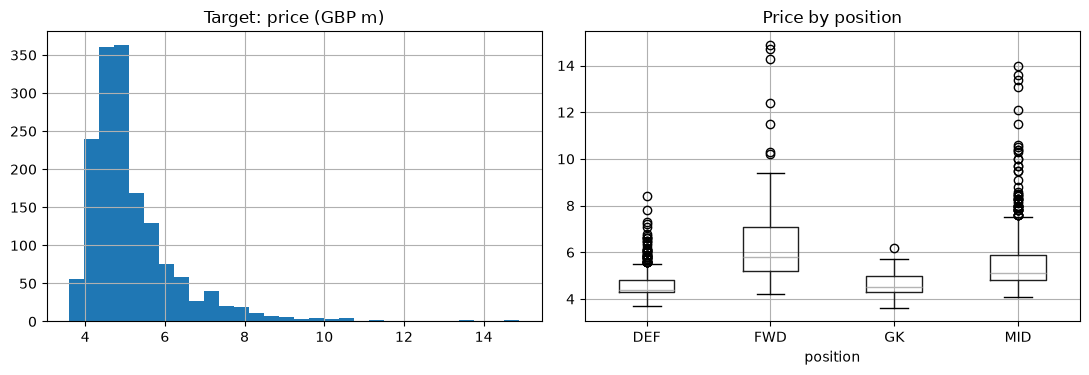

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
features['price_m'].hist(bins=30, ax=ax[0])
ax[0].set_title('Target: price (GBP m)')
features.boxplot(column='price_m', by='position', ax=ax[1])
ax[1].set_title('Price by position')
plt.suptitle(''); plt.tight_layout()

## 2. Season-held-out cross-validation

Each fold is scored on a season the model never trained on. The mean-price baseline is the bar to clear.

In [4]:
cross_validate_by_season(features).round(3)

,mae_m,r2
estimator,,
gbr,0.500,0.599
ridge,0.531,0.572
linear,0.534,0.570
baseline_mean,0.831,-0.003


## 3. Predicted vs actual price (linear model)

Refit on every season, then look at the fit and the residuals. Points far above the diagonal are players the model prices higher than the market: its underpriced picks.

Text(0.5, 1.0, 'Linear model: predicted vs actual')

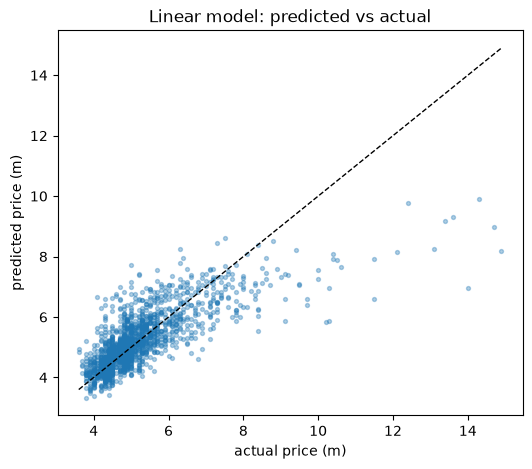

In [5]:
model = ValueModel().fit(features)
scored = model.score_frame(features)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(scored['price_m'], scored['pred_m'], s=8, alpha=0.35)
lims = [scored['price_m'].min(), scored['price_m'].max()]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('actual price (m)'); ax.set_ylabel('predicted price (m)')
ax.set_title('Linear model: predicted vs actual')

In [6]:
cols = ['name', 'season', 'position', 'price_m', 'pred_m', 'value_m']
print('Most underpriced (historical seasons):')
display(scored.head(10)[cols].round(2))
print('Most overpriced (historical seasons):')
display(scored.tail(10)[cols].round(2))

Most underpriced (historical seasons):


,name,season,position,price_m,pred_m,value_m
0,Deniz Undav,2022-23,FWD,5.0,7.72,2.72
1,Alejandro Garnacho,2022-23,MID,4.1,6.67,2.57
2,Rodrigo Muniz Carvalho,2023-24,FWD,4.3,6.61,2.31
3,Chris Wood,2023-24,FWD,4.7,6.99,2.29
4,Taiwo Awoniyi,2025-26,FWD,5.2,7.43,2.23
5,João Pedro Junqueira de Jesus,2023-24,FWD,5.2,7.39,2.19
6,Lukas Nmecha,2025-26,FWD,5.0,7.15,2.15
7,Julio Enciso,2022-23,FWD,4.6,6.75,2.15
8,Dango Ouattara,2024-25,MID,4.5,6.62,2.12
9,Evan Ferguson,2022-23,FWD,4.6,6.70,2.10


Most overpriced (historical seasons):


,name,season,position,price_m,pred_m,value_m
1598,Mohamed Salah,2023-24,MID,13.4,9.17,-4.23
1599,Mohamed Salah,2024-25,MID,13.6,9.31,-4.29
1600,Cristiano Ronaldo dos Santos Aveiro,2022-23,FWD,10.2,5.83,-4.37
1601,Erling Haaland,2023-24,FWD,14.3,9.89,-4.41
1602,Alexander Isak,2025-26,FWD,10.3,5.88,-4.42
1603,Mohamed Salah,2022-23,MID,13.1,8.26,-4.84
1604,Son Heung-min,2022-23,MID,11.5,6.60,-4.90
1605,Erling Haaland,2025-26,FWD,14.7,8.97,-5.73
1606,Erling Haaland,2024-25,FWD,14.9,8.19,-6.71
1607,Mohamed Salah,2025-26,MID,14.0,6.97,-7.03


## 4. Does the value signal pick better squads?

Walk-forward: fit on earlier seasons, draft the top 20 of each ranking from the prior season, and score them on the *next* season's points per million of acquisition cost. Higher is better.

In [7]:
walk_forward_backtest(history, top_n=20).round(2)

,2023-24,2024-25,2025-26,mean
fpl_form,19.30,17.49,19.76,18.85
model_value,17.05,18.94,19.85,18.61
points_per90,16.16,17.48,11.39,15.01
cheapest,12.60,11.69,15.88,13.39


## 5. Current player pool

Live players scored on a blend of this season's form and their most recent completed season's, weighted by minutes played so far. Players with no personal PL history (new signings, promoted-team players, academy graduates) get a position-average prediction instead of being dropped -- flagged via `has_history` since it's a much weaker signal. Unavailable players (injured/suspended/unregistered) are flagged via `available` rather than silently ranked.

In [8]:
live_scored = model.score_frame(attach_history_features(live, history))
live_cols = ['name', 'position', 'price_m', 'pred_m', 'value_m', 'total_points', 'status']
print(f'{len(live_scored)} of {len(live)} live players scored')

no_history = ~live_scored['has_history']
print(f'{no_history.sum()} have no personal PL history and are priced on a position average only')

unavailable = ~live_scored['available']
print(f'{unavailable.sum()} are currently injured, suspended, or unregistered (status != "a")')

# Primary signal: players with their own track record who are actually available.
trusted = live_scored[live_scored['has_history'] & live_scored['available']]
print('\nModel thinks these are underpriced (own history, available):')
display(trusted.head(15)[live_cols].round(2))
print('Model thinks these are overpriced (own history, available):')
display(trusted.tail(15)[live_cols].round(2))

print('\nUnavailable players that would otherwise rank in the top 15 underpriced (buyer beware):')
display(live_scored[unavailable].sort_values('value_m', ascending=False).head(15)[live_cols].round(2))

print('\nNo personal history -- position-average price only, treat as speculative:')
display(live_scored[no_history].sort_values('value_m', ascending=False).head(15)[live_cols].round(2))

667 of 667 live players scored
289 have no personal PL history and are priced on a position average only
201 are currently injured, suspended, or unregistered (status != "a")

Model thinks these are underpriced (own history, available):


,name,position,price_m,pred_m,value_m,total_points,status
5,David Brooks,MID,5.0,6.66,1.66,3,a
13,Lukas Nmecha,FWD,5.4,6.93,1.53,7,a
20,Callum Wilson,FWD,5.4,6.76,1.36,3,a
23,Eddie Nketiah,FWD,5.5,6.86,1.36,8,a
26,Joshua Zirkzee,FWD,5.3,6.57,1.27,2,a
44,Thierno Barry,FWD,5.6,6.61,1.01,20,a
51,Wilson Isidor,FWD,5.5,6.44,0.94,15,a
52,Danny Welbeck,FWD,5.9,6.82,0.92,4,a
59,Leif Davis,DEF,4.0,4.88,0.88,25,a
73,Rico Lewis,DEF,4.4,5.18,0.78,1,a


Model thinks these are overpriced (own history, available):


,name,position,price_m,pred_m,value_m,total_points,status
648,James Hill,DEF,5.5,4.40,-1.10,12,a
649,Morgan Rogers,MID,7.7,6.60,-1.10,29,a
650,Nico González Iglesias,MID,5.5,4.37,-1.13,5,a
652,James Tarkowski,DEF,6.1,4.75,-1.35,43,a
654,Jarrad Branthwaite,DEF,5.5,4.02,-1.48,27,a
655,Morgan Gibbs-White,MID,8.0,6.52,-1.48,28,a
656,Omar Marmoush,FWD,7.0,5.46,-1.54,8,a
657,Virgil van Dijk,DEF,6.5,4.94,-1.56,25,a
658,Matheus Santos Carneiro da Cunha,MID,7.9,6.24,-1.66,26,a
659,Bukayo Saka,MID,9.5,7.80,-1.70,32,a



Unavailable players that would otherwise rank in the top 15 underpriced (buyer beware):


,name,position,price_m,pred_m,value_m,total_points,status
1,Chido Obi,FWD,4.5,6.63,2.13,0,u
3,Dane Scarlett,FWD,4.5,6.25,1.75,0,u
4,Kaye Furo,FWD,4.5,6.25,1.75,0,i
6,Emmanuel Emegha,FWD,5.0,6.63,1.63,0,i
7,Marc Guiu Paz,FWD,5.0,6.63,1.63,0,u
8,Sean Neave,FWD,4.5,6.06,1.56,0,u
9,Mateo Joseph Fernández-Regatillo,FWD,4.5,6.06,1.56,0,i
16,Divine Mukasa,MID,4.5,5.95,1.45,0,u
17,Norman Bassette,FWD,4.5,5.87,1.37,0,u
18,Mason Burstow,FWD,4.5,5.87,1.37,0,u



No personal history -- position-average price only, treat as speculative:


,name,position,price_m,pred_m,value_m,total_points,status
0,Shumaira Mheuka,FWD,4.5,6.63,2.13,0,a
1,Chido Obi,FWD,4.5,6.63,2.13,0,u
2,Jayden Danns,FWD,4.5,6.63,2.13,0,a
3,Dane Scarlett,FWD,4.5,6.25,1.75,0,u
4,Kaye Furo,FWD,4.5,6.25,1.75,0,i
6,Emmanuel Emegha,FWD,5.0,6.63,1.63,0,i
7,Marc Guiu Paz,FWD,5.0,6.63,1.63,0,u
8,Sean Neave,FWD,4.5,6.06,1.56,0,u
9,Mateo Joseph Fernández-Regatillo,FWD,4.5,6.06,1.56,0,i
10,Jonah Kusi-Asare,FWD,4.5,6.06,1.56,0,a


## Notes

- Linear and ridge sit on top of each other; GBR is marginally ahead on MAE. Keep linear as the default for interpretability.
- Premium players (Haaland, Salah, Bruno) always read as 'overpriced': a linear model on per-90 counting stats can't see the captaincy / ownership / fixture-proof premium. Documented in `PROJECT.md`.
- The value signal beats raw FPL form only narrowly in the backtest.
- Done: live scoring blends this-season form with last season's (weighted by minutes played so far); carries FPL's `status`/`chance_of_playing_next_round` through as an `available` flag; falls back to a position average (flagged `has_history=False`) instead of dropping players with no personal PL history; and adds team strength as a feature, taken straight from the player's *current* club rather than blended across a transfer.
- Team strength fix: FPL's absolute strength scale isn't comparable across seasons or even between the live API (~1-5 scale) and the historical mirror (~1200-1400 scale). Fixed by z-scoring each source's teams independently, so the feature is "how strong is this team relative to its 19 rivals that season" everywhere -- comparable regardless of source or scale drift. This measurably helped: gbr MAE 0.542 -> 0.500, R² 0.551 -> 0.599 in season-held-out CV.
- Tried and rejected: separate models per position -- tested via season-held-out CV and every position got *worse* (e.g. MID MAE 0.596->0.639, R² 0.473->0.369) versus the pooled model with position as a feature. Not worth the added complexity.
- Known tradeoff of the position-average fallback: ~13 minimum-priced academy fringe players can tie for the same predicted value, since the model has nothing to tell them apart beyond position and price floor. The current player-pool section keeps them out of the primary underpriced/overpriced lists (filtered to `has_history & available`) and surfaces them separately as speculative.
- Next idea: predict forward points directly instead of price -- the more direct fix for the premium-player residual, but it redefines the model's target (see `PROJECT.md`), so needs a decision before building. Would also need new data: per-gameweek history (vaastav's `gws/merged_gw.csv` per season), which isn't fetched today.